1. DATA EXPLORATION

Import

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.naive_bayes import GaussianNB

Load Dataset

In [12]:
df = pd.read_csv("social_media_usage.csv")

Data Identification

In [13]:
print("Jumlah Record :", df.shape[0])
print("Jumlah Variabel :", df.shape[1])
df.info()   

Jumlah Record : 50000
Jumlah Variabel : 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      50000 non-null  int64  
 1   year                         50000 non-null  int64  
 2   country                      50000 non-null  object 
 3   age_group                    50000 non-null  object 
 4   gender                       50000 non-null  object 
 5   platform                     50000 non-null  object 
 6   daily_screen_time_hours      50000 non-null  float64
 7   doomscrolling_frequency      50000 non-null  float64
 8   notification_checks_per_day  50000 non-null  int64  
 9   ai_recommendation_exposure   50000 non-null  float64
 10  productivity_loss_pct        50000 non-null  float64
 11  digital_detox_attempts       50000 non-null  int64  
 12  addiction_risk_level         50

In [14]:
df.head()

,user_id,year,country,age_group,gender,platform,daily_screen_time_hours,doomscrolling_frequency,notification_checks_per_day,ai_recommendation_exposure,productivity_loss_pct,digital_detox_attempts,addiction_risk_level
0,7857,2036,UK,Senior,Female,Facebook,6.10,9.69,333,86.08,32.66,11,Low
1,21853,2060,Italy,Senior,Other,YouTube,7.61,4.22,246,76.60,24.24,6,Low
2,8524,2060,USA,Children,Female,YouTube,9.01,6.16,107,6.23,69.08,14,High
3,12728,2049,China,Children,Male,Twitch,3.98,5.61,214,27.73,20.08,2,Medium
4,14938,2058,Australia,Senior,Male,Snapchat,4.06,9.43,111,37.88,64.55,6,Low


2. Data Preparation

Cek Missing Value

In [15]:
df.isnull().sum()

user_id                        0
year                           0
country                        0
age_group                      0
gender                         0
platform                       0
daily_screen_time_hours        0
doomscrolling_frequency        0
notification_checks_per_day    0
ai_recommendation_exposure     0
productivity_loss_pct          0
digital_detox_attempts         0
addiction_risk_level           0
dtype: int64

In [16]:
df = df.dropna()

Data Selection

In [17]:
X = df[
[
    'daily_screen_time_hours',
    'doomscrolling_frequency',
    'notification_checks_per_day',
    'ai_recommendation_exposure',
    'productivity_loss_pct',
    'digital_detox_attempts'
]
]
X.head()

,daily_screen_time_hours,doomscrolling_frequency,notification_checks_per_day,ai_recommendation_exposure,productivity_loss_pct,digital_detox_attempts
0,6.10,9.69,333,86.08,32.66,11
1,7.61,4.22,246,76.60,24.24,6
2,9.01,6.16,107,6.23,69.08,14
3,3.98,5.61,214,27.73,20.08,2
4,4.06,9.43,111,37.88,64.55,6


In [18]:
X.describe()

,daily_screen_time_hours,doomscrolling_frequency,notification_checks_per_day,ai_recommendation_exposure,productivity_loss_pct,digital_detox_attempts
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,5.995321,5.017518,177.297700,50.196940,35.101957,6.982880
std,1.990299,2.883153,99.651905,28.919281,20.173603,4.323679
min,0.500000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,4.650000,2.530000,91.000000,25.100000,17.610000,3.000000
50%,5.990000,5.030000,178.000000,50.190000,35.230000,7.000000
75%,7.340000,7.520000,264.000000,75.232500,52.632500,11.000000
max,14.660000,10.000000,349.000000,100.000000,69.990000,14.000000


Standardisasi

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
pd.DataFrame(
    X_scaled,
    columns=X.columns
).head()

,daily_screen_time_hours,doomscrolling_frequency,notification_checks_per_day,ai_recommendation_exposure,productivity_loss_pct,digital_detox_attempts
0,0.052595,1.620631,1.562477,1.240813,-0.121048,0.929107
1,0.811283,-0.276616,0.689430,0.913001,-0.538430,-0.227327
2,1.514702,0.396265,-0.705440,-1.520348,1.684299,1.622967
3,-1.012582,0.205500,0.368309,-0.776892,-0.744642,-1.152474
4,-0.972387,1.530451,-0.665300,-0.425912,1.459746,-0.227327


Encoding

In [21]:
le = LabelEncoder()

df['addiction_label'] = le.fit_transform(
    df['addiction_risk_level']
)

In [22]:
df[
[
'addiction_risk_level',
'addiction_label'
]
].head()

,addiction_risk_level,addiction_label
0,Low,1
1,Low,1
2,High,0
3,Medium,2
4,Low,1


3. K-Means Clustering (Unsupervised Learning)

K-Means

In [23]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [24]:
df['cluster'].value_counts()

cluster
0    25025
1    24975
Name: count, dtype: int64

Visualisasi Jumlah Cluster

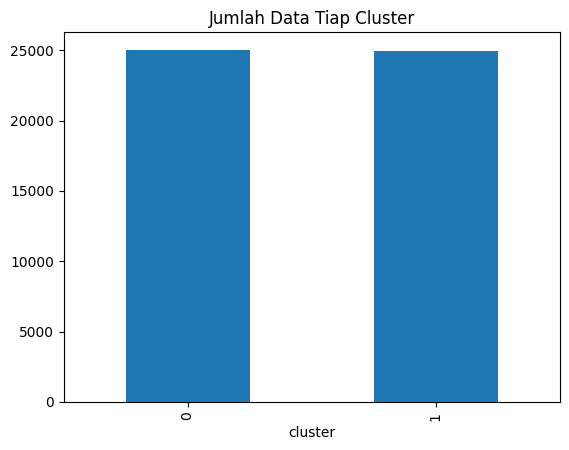

In [25]:
df['cluster'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Jumlah Data Tiap Cluster'
)

plt.show()

Silhouette Score

In [26]:
score = silhouette_score(
    X_scaled,
    df['cluster']
)

print(
    "Silhouette Score :",score)

Silhouette Score : 0.12509860883361332


Profil Cluster

In [27]:
cluster_profile = df.groupby('cluster')[
[
    'daily_screen_time_hours',
    'doomscrolling_frequency',
    'notification_checks_per_day',
    'ai_recommendation_exposure',
    'productivity_loss_pct',
    'digital_detox_attempts'
]
].mean()

cluster_profile

,daily_screen_time_hours,doomscrolling_frequency,notification_checks_per_day,ai_recommendation_exposure,productivity_loss_pct,digital_detox_attempts
cluster,,,,,,
0,5.975100,4.844888,175.979740,49.484644,34.683199,3.248232
1,6.015582,5.190494,178.618298,50.910661,35.521553,10.725005


Visualisasi Profil Cluster

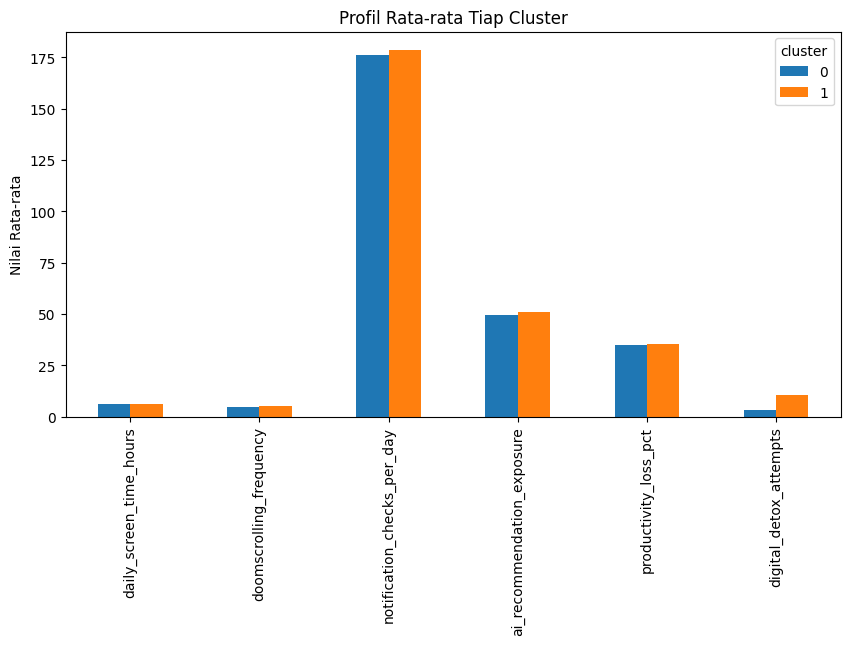

In [28]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Profil Rata-rata Tiap Cluster')
plt.ylabel('Nilai Rata-rata')

plt.show()

4. Logistic Regression (Supervised Learning)

Split Data

In [29]:
X = df[
[
'daily_screen_time_hours',
'doomscrolling_frequency',
'notification_checks_per_day',
'ai_recommendation_exposure',
'productivity_loss_pct',
'digital_detox_attempts'
]
]

y = df['addiction_label']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Standardisasi untuk Klasifikasi

In [31]:
scaler_cls = StandardScaler()

X_train_scaled = scaler_cls.fit_transform(
    X_train
)

X_test_scaled = scaler_cls.transform(
    X_test
)

Training Model

In [32]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

Prediksi

In [33]:
y_pred_lr = lr.predict(X_test)

Evaluasi

In [34]:
print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print(
    "Precision :",
    precision_score(
        y_test,
        y_pred_lr,
        average='weighted'
    )
)

print(
    "Recall :",
    recall_score(
        y_test,
        y_pred_lr,
        average='weighted'
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_lr,
        average='weighted'
    )
)

Accuracy : 0.4979
Precision : 0.24790441000000002
Recall : 0.4979
F1 Score : 0.33100261699712935


c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

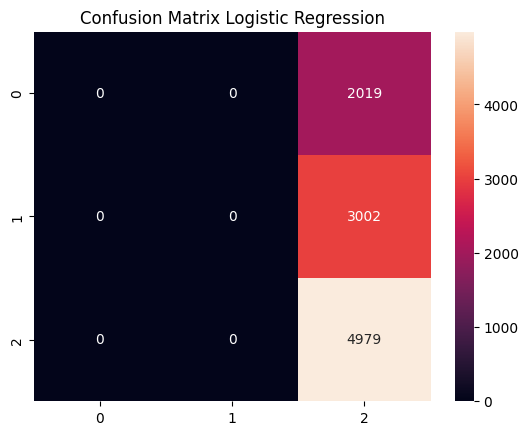

In [35]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Confusion Matrix Logistic Regression'
)

plt.show()

Classification Report

In [36]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2019
           1       0.00      0.00      0.00      3002
           2       0.50      1.00      0.66      4979

    accuracy                           0.50     10000
   macro avg       0.17      0.33      0.22     10000
weighted avg       0.25      0.50      0.33     10000



c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

5. Naïve Bayes Classifier (Supervised Learning)

Training Model

In [37]:
nb = GaussianNB()

nb.fit(
    X_train_scaled,
    y_train
)

GaussianNB()

Prediksi

In [38]:
y_pred_nb = nb.predict(X_test)

Evaluasi

In [39]:
print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_nb
    )
)

print(
    "Precision :",
    precision_score(
        y_test,
        y_pred_nb,
        average='weighted'
    )
)

print(
    "Recall :",
    recall_score(
        y_test,
        y_pred_nb,
        average='weighted'
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_nb,
        average='weighted'
    )
)

Accuracy : 0.4979
Precision : 0.24790441000000002
Recall : 0.4979
F1 Score : 0.33100261699712935


c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

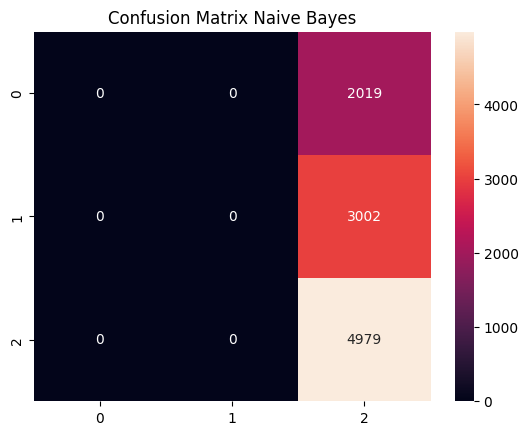

In [40]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d'
)

plt.title(
    'Confusion Matrix Naive Bayes'
)

plt.show()

Classification Report

In [41]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2019
           1       0.00      0.00      0.00      3002
           2       0.50      1.00      0.66      4979

    accuracy                           0.50     10000
   macro avg       0.17      0.33      0.22     10000
weighted avg       0.25      0.50      0.33     10000



c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

6. Perbandingan Model

Tabel Perbandingan

In [42]:
hasil = pd.DataFrame({
    'Model' : [
        'Logistic Regression',
        'Naive Bayes'
    ],

    'Accuracy' : [
        accuracy_score(
            y_test,
            y_pred_lr
        ),
        accuracy_score(
            y_test,
            y_pred_nb
        )
    ],

    'Precision' : [
        precision_score(
            y_test,
            y_pred_lr,
            average='weighted'
        ),
        precision_score(
            y_test,
            y_pred_nb,
            average='weighted'
        )
    ],

    'Recall' : [
        recall_score(
            y_test,
            y_pred_lr,
            average='weighted'
        ),
        recall_score(
            y_test,
            y_pred_nb,
            average='weighted'
        )
    ],

    'F1 Score' : [
        f1_score(
            y_test,
            y_pred_lr,
            average='weighted'
        ),
        f1_score(
            y_test,
            y_pred_nb,
            average='weighted'
        )
    ]
})

hasil

c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\infinix\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.4979,0.247904,0.4979,0.331003
1,Naive Bayes,0.4979,0.247904,0.4979,0.331003


Grafik Perbandingan

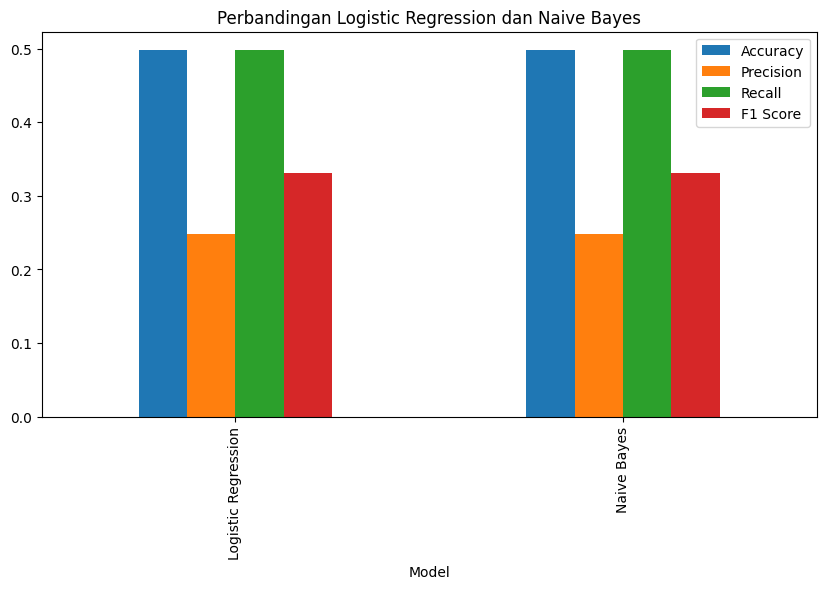

In [43]:
hasil.set_index(
    'Model'
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Perbandingan Logistic Regression dan Naive Bayes'
)

plt.show()

Simpan Hasil

In [44]:
hasil.to_csv(
    "hasil_model.csv",
    index=False
)

7. Dashboard

Menyimpan Dataset Dashboard

In [45]:
df_dashboard = df.copy()

df_dashboard.to_csv(
    "hasil_cluster.csv",
    index=False
)

Menyimpan Model

In [46]:
import joblib

joblib.dump(
    lr,
    "model_logreg.pkl"
)

joblib.dump(
    scaler_cls,
    "scaler.pkl"
)

joblib.dump(
    le,
    "label_encoder.pkl"
)

['label_encoder.pkl']